Cell 1 - Install Ultralytics (for YOLOv10)

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.3 MB/s eta 0:00:00


Cell 2 - Import Libraries

In [2]:
from ultralytics import YOLO

import os
import cv2
import yaml
import random
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Cell 3 - Auto-Detect Dataset Path (attached via Kaggle 'Add Input' -> jayasuryak24csr114/construction-ppe-dataset)

In [3]:
# On Kaggle, attached datasets are mounted read-only under /kaggle/input/<dataset-slug>/.
# We search for the folder that actually contains data.yaml, since Kaggle sometimes nests
# the real dataset one level deeper than the slug folder.

KAGGLE_INPUT = "/kaggle/input"

def find_dataset_root(base):
    for root, dirs, files in os.walk(base):
        if "data.yaml" in files:
            return root
    return None

dataset_path = find_dataset_root(KAGGLE_INPUT)

assert dataset_path is not None, (
    "Could not find data.yaml under /kaggle/input. "
    "Make sure the 'construction-ppe-dataset' dataset is attached to this notebook "
    "(Notebook -> Add Input -> search 'construction-ppe-dataset')."
)

print("Detected dataset_path:", dataset_path)

Detected dataset_path: /kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset


Cell 3b - Resolve Train/Val/Test Folders and Rebuild data.yaml (Kaggle input is read-only, so we write a working copy)

In [4]:
# Kaggle datasets show up in two different folder conventions depending on how they were
# exported:
#   split-first : train/images, train/labels, val/images, val/labels, test/images, test/labels
#   type-first  : images/train, labels/train, images/val,  labels/val,  images/test,  labels/test
def resolve_split_dirs(base, split):
    split_first = (os.path.join(base, split, "images"), os.path.join(base, split, "labels"))
    type_first  = (os.path.join(base, "images", split), os.path.join(base, "labels", split))
    if os.path.isdir(split_first[0]) and os.path.isdir(split_first[1]):
        return split_first
    if os.path.isdir(type_first[0]) and os.path.isdir(type_first[1]):
        return type_first
    raise FileNotFoundError(f"Could not find images+labels folders for split \'{split}\' under {base}")

TRAIN_IMG, TRAIN_LBL = resolve_split_dirs(dataset_path, "train")
VAL_IMG,   VAL_LBL   = resolve_split_dirs(dataset_path, "val")
TEST_IMG,  TEST_LBL  = resolve_split_dirs(dataset_path, "test")

print("train images/labels:", TRAIN_IMG, "|", TRAIN_LBL)
print("val   images/labels:", VAL_IMG, "|", VAL_LBL)
print("test  images/labels:", TEST_IMG, "|", TEST_LBL)

# /kaggle/input is read-only, so the original data.yaml (which may point at Drive/Colab
# paths) cannot be used directly. We pull just the class "names" out of it and write a
# fresh data.yaml with correct Kaggle paths into /kaggle/working/.
with open(os.path.join(dataset_path, "data.yaml")) as f:
    orig_cfg = yaml.safe_load(f)

class_names = orig_cfg["names"]

data_yaml = {
    "train": TRAIN_IMG,
    "val": VAL_IMG,
    "test": TEST_IMG,
    "nc": len(class_names),
    "names": class_names,
}

os.makedirs("/kaggle/working", exist_ok=True)
DATA = "/kaggle/working/data.yaml"
with open(DATA, "w") as f:
    yaml.safe_dump(data_yaml, f)

print("Wrote working data.yaml to:", DATA)
print(data_yaml)

train images/labels: /kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/train/images | /kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/train/labels
val   images/labels: /kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/val/images | /kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/val/labels
test  images/labels: /kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/test/images | /kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/test/labels
Wrote working data.yaml to: /kaggle/working/data.yaml
{'train': '/kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/train/images', 'val': '/kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/val/images', 'test': '/kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PP

Cell 4 - Count Images & Labels

In [5]:
print("Train Images :", len(os.listdir(TRAIN_IMG)))
print("Train Labels :", len(os.listdir(TRAIN_LBL)))

print()

print("Validation Images :", len(os.listdir(VAL_IMG)))
print("Validation Labels :", len(os.listdir(VAL_LBL)))

print()

print("Test Images :", len(os.listdir(TEST_IMG)))
print("Test Labels :", len(os.listdir(TEST_LBL)))

Train Images : 8400
Train Labels : 8400

Validation Images : 2400
Validation Labels : 2400

Test Images : 1200
Test Labels : 1200


Cell 5 - Check if Images and Labels Match

In [6]:
train_images = os.listdir(TRAIN_IMG)
train_labels = os.listdir(TRAIN_LBL)

print("Total train images:", len(train_images))
print("Total train labels:", len(train_labels))

if len(train_images) != len(train_labels):
    print("Warning: image count and label count do not match. Please check your dataset.")
else:
    print("Images and labels match.")

Total train images: 8400
Total train labels: 8400
Images and labels match.


Cell 6 - Find Which Labels Have No Matching Image

In [7]:
image_names = set()
for f in train_images:
    name = f.rsplit(".", 1)[0]
    image_names.add(name)

label_names = set()
for f in train_labels:
    if f.endswith(".txt"):
        name = f.rsplit(".", 1)[0]
        label_names.add(name)

extra_labels = label_names - image_names

print("Labels with no matching image:", len(extra_labels))
print(extra_labels)

Labels with no matching image: 0
set()


Cell 7 - Verify Class Distribution

In [8]:
class_count = {}

for file in os.listdir(TRAIN_LBL):
    with open(os.path.join(TRAIN_LBL, file), "r") as f:
        for line in f.readlines():
            if not line.strip():
                continue
            cls = int(line.split()[0])
            class_count[cls] = class_count.get(cls, 0) + 1

print("Class Distribution\n")

for k, v in sorted(class_count.items()):
    print("Class", k, ":", v)

Class Distribution

Class 0 : 7619
Class 1 : 4903
Class 2 : 3836
Class 3 : 4176
Class 4 : 1434
Class 5 : 2969
Class 6 : 3597
Class 7 : 1479
Class 8 : 3477
Class 9 : 92


Cell 8 - Load YOLOv10

In [9]:
# YOLOv10 nano checkpoint. Swap for yolov10s.pt / yolov10m.pt / yolov10l.pt / yolov10x.pt
# for a bigger/more accurate model (slower to train).
model = YOLO("yolov10n.pt")

print("YOLOv10 loaded successfully")

YOLOv10 loaded successfully


Cell 9 - Configure Training

In [10]:
# DATA now points at the data.yaml we rebuilt in /kaggle/working (see Cell 3b),
# not the read-only copy under /kaggle/input.

EPOCHS = 100

IMAGE_SIZE = 640

BATCH = 16

print(DATA)

/kaggle/working/data.yaml


Cell 10 - Data Augmentation

In [11]:
augmentation = {

"mosaic":1.0,

"fliplr":0.5,

"degrees":10,

"translate":0.1,

"scale":0.5

}

print(augmentation)

{'mosaic': 1.0, 'fliplr': 0.5, 'degrees': 10, 'translate': 0.1, 'scale': 0.5}


Cell 11 - Train YOLOv10 (Kaggle: make sure Settings -> Accelerator -> GPU T4 x2 / P100 is enabled)

In [12]:
train_results = model.train(
    data=DATA,
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH,
    device=0,
    mosaic=1.0,
    fliplr=0.5,
    degrees=10,
    translate=0.1,
    scale=0.5,
    workers=0, # Set workers to 0 to avoid multiprocessing data loading issues
    project="/kaggle/working/runs", # keep all outputs on the writable Kaggle working dir
)

# Save the exact run folder Ultralytics created (train, train2, train3, ...) so later cells
# never have to guess the path.
RUN_DIR = str(model.trainer.save_dir)
print("Run outputs saved at:", RUN_DIR)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=No

Cell 12 - Validate Model

In [13]:
metrics = model.val()

print("Validation Completed")

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv10n summary (fused): 102 layers, 2,267,118 parameters, 0 gradients, 6.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 140.1±125.4 MB/s, size: 89.7 KB)
val: Scanning /kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/val/labels... 2400 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2400/2400 917.1it/s 2.6s
val: /kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/val/images/ds4__Video2_167_jpg.rf.0534d2d45018cf5cb74e3c2f673bc600.jpg: 1 duplicate labels removed
val: /kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/val/images/ds4__Video2_167_jpg.rf.d8c3c42530770d9dfe4e90cbef50acec.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/jayasuryak24csr114/construction-ppe-dataset/PPE_Final_Dataset/val is not writable, cache not saved.
                 Clas

Cell 13 - Precision

In [14]:
print("Precision :", metrics.box.mp)

Precision : 0.8532220544336073


Cell 14 - Recall

In [15]:
print("Recall :", metrics.box.mr)

Recall : 0.8296716952830054


Cell 15 - mAP Score

In [16]:
print("mAP@50 :", metrics.box.map50)

print("mAP@50-95 :", metrics.box.map)

mAP@50 : 0.8723778012255157
mAP@50-95 : 0.5582046250459946


Cell 16 - Per-Class Accuracy (mAP@50)

In [17]:
with open(DATA) as f:
    data_cfg = yaml.safe_load(f)
class_names = data_cfg["names"]

print("Per-Class mAP@50\n")

for idx, class_id in enumerate(metrics.box.ap_class_index):
    class_name = class_names[class_id]
    class_map50 = metrics.box.ap50[idx]
    print(class_name, ":", round(class_map50, 3))

Per-Class mAP@50

helmet : 0.889
gloves : 0.875
vest : 0.933
boots : 0.99
goggles : 0.94
Person : 0.85
no_helmet : 0.864
no_goggle : 0.918
no_gloves : 0.879
no_boots : 0.585


Cell 17 - Display Confusion Matrix

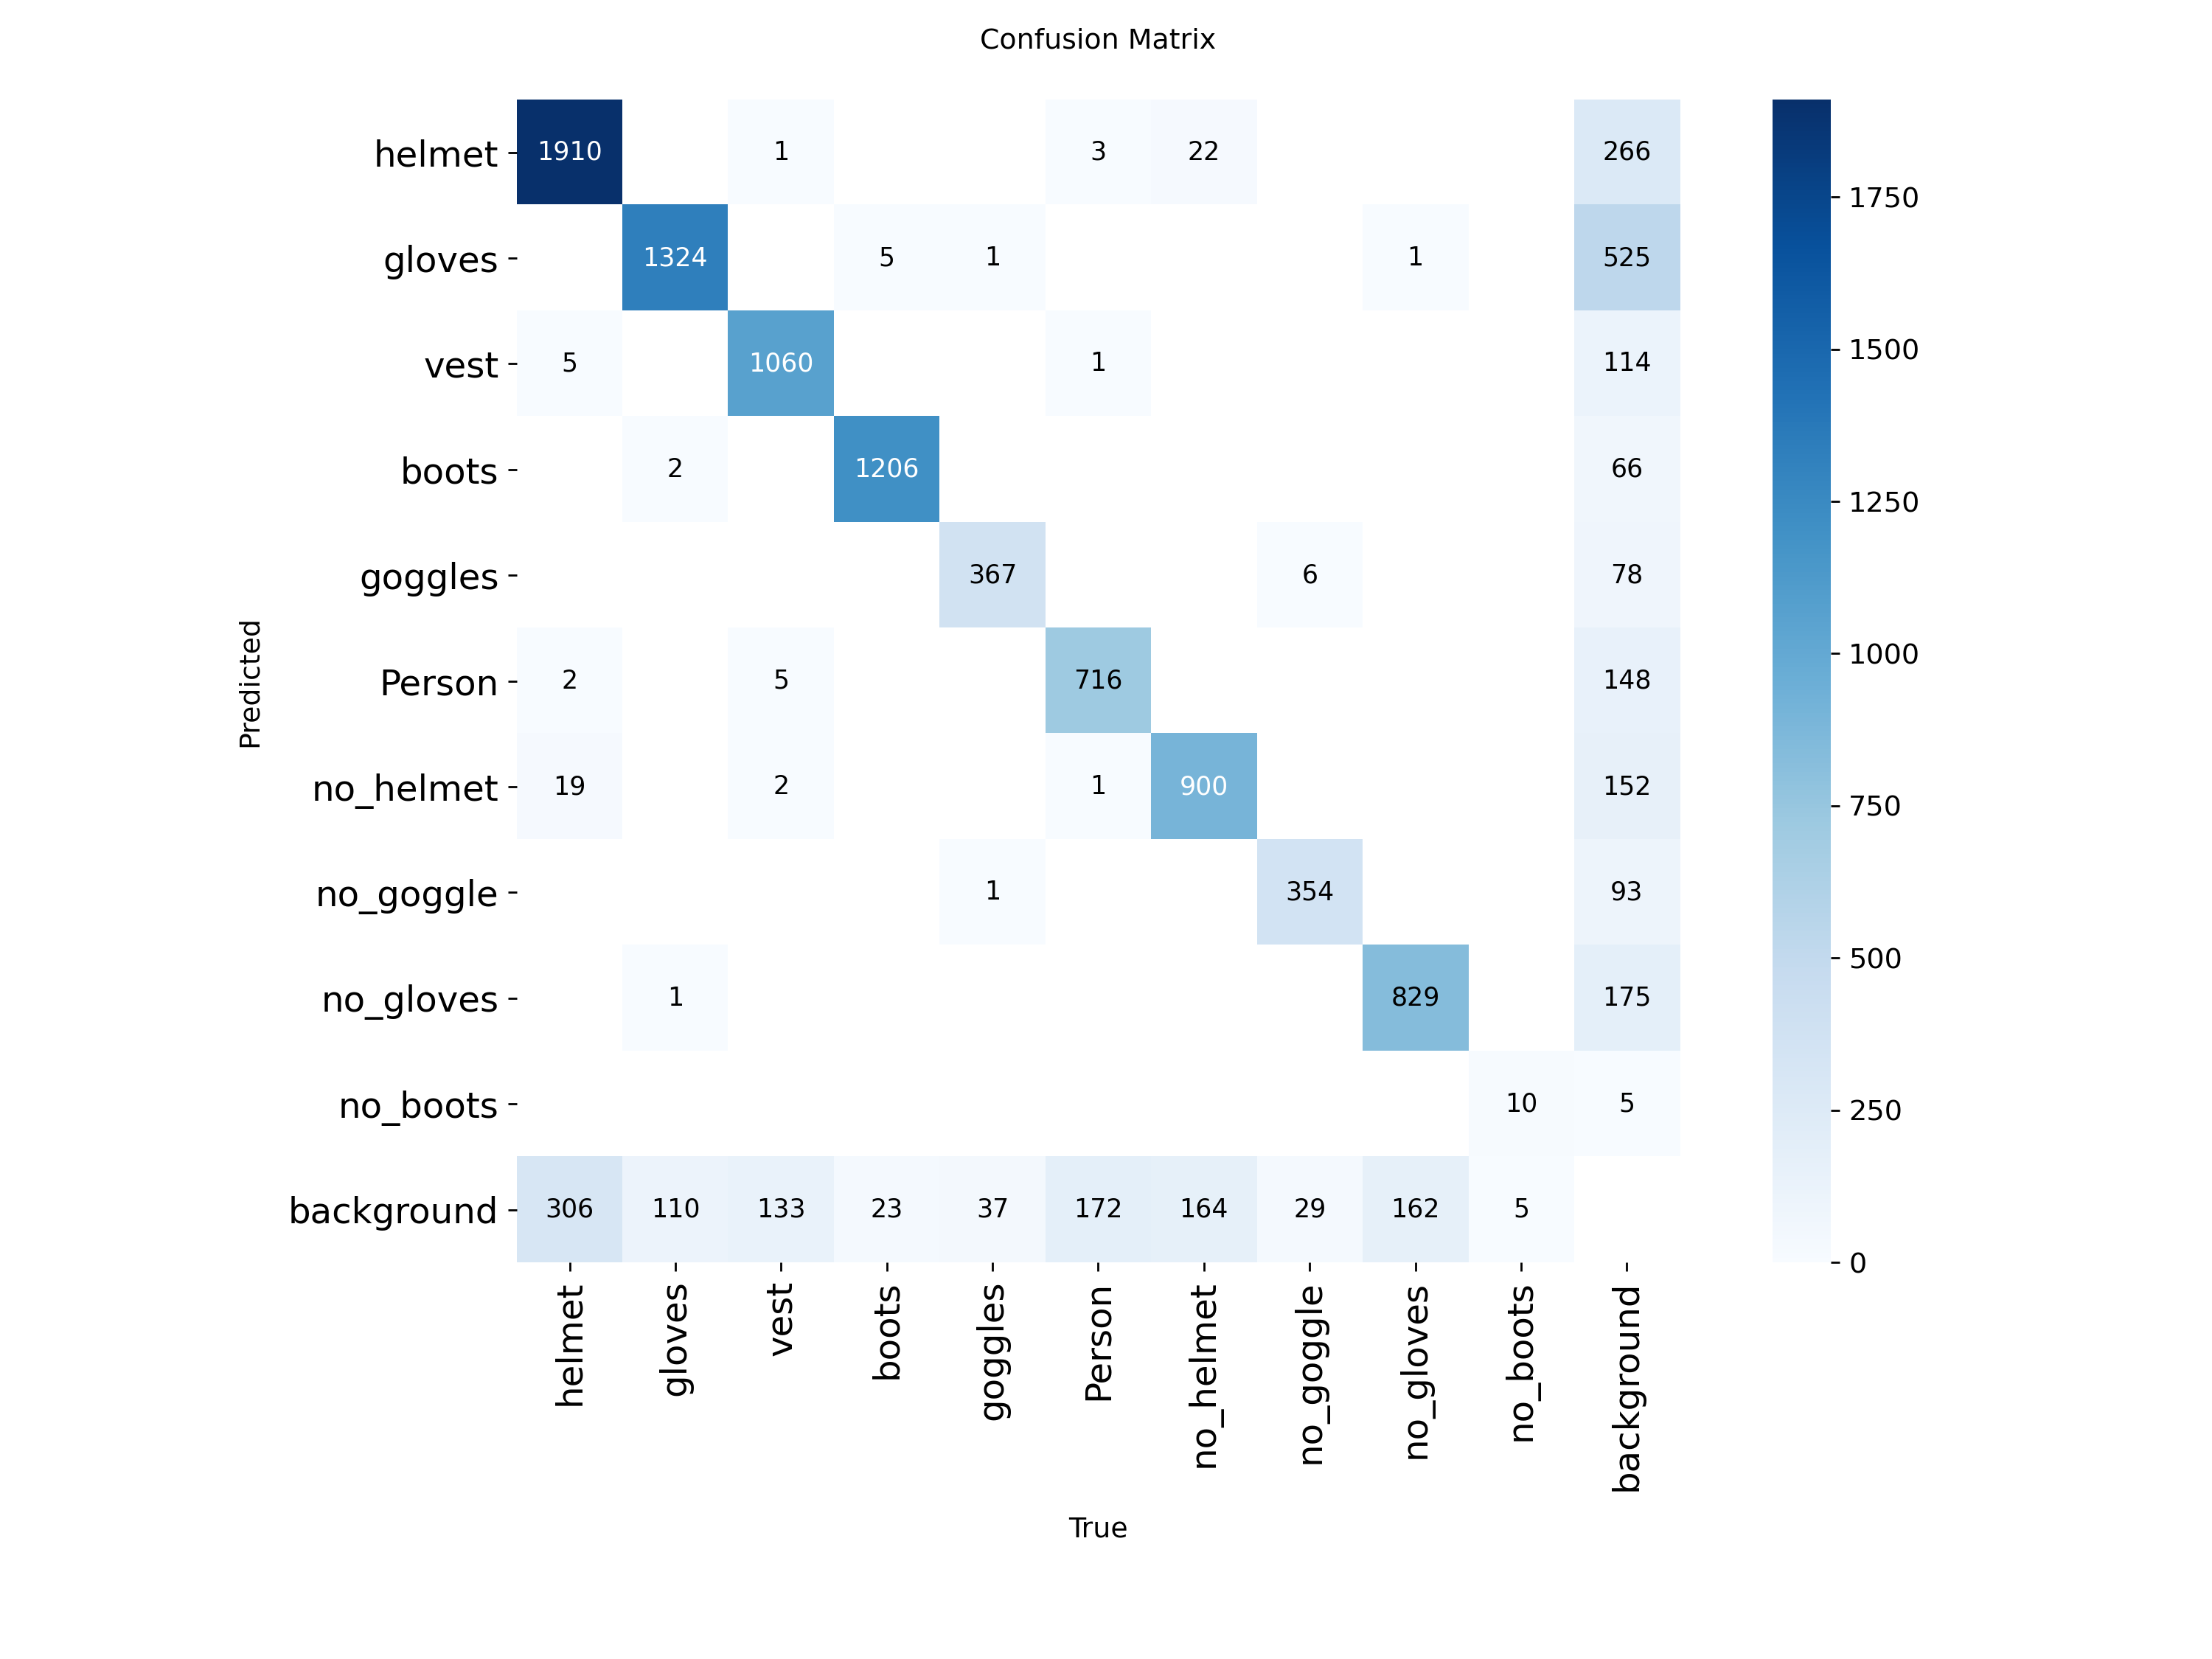

In [18]:
from IPython.display import Image

Image(f"{RUN_DIR}/confusion_matrix.png")

Cell 18 - Display F1 Curve

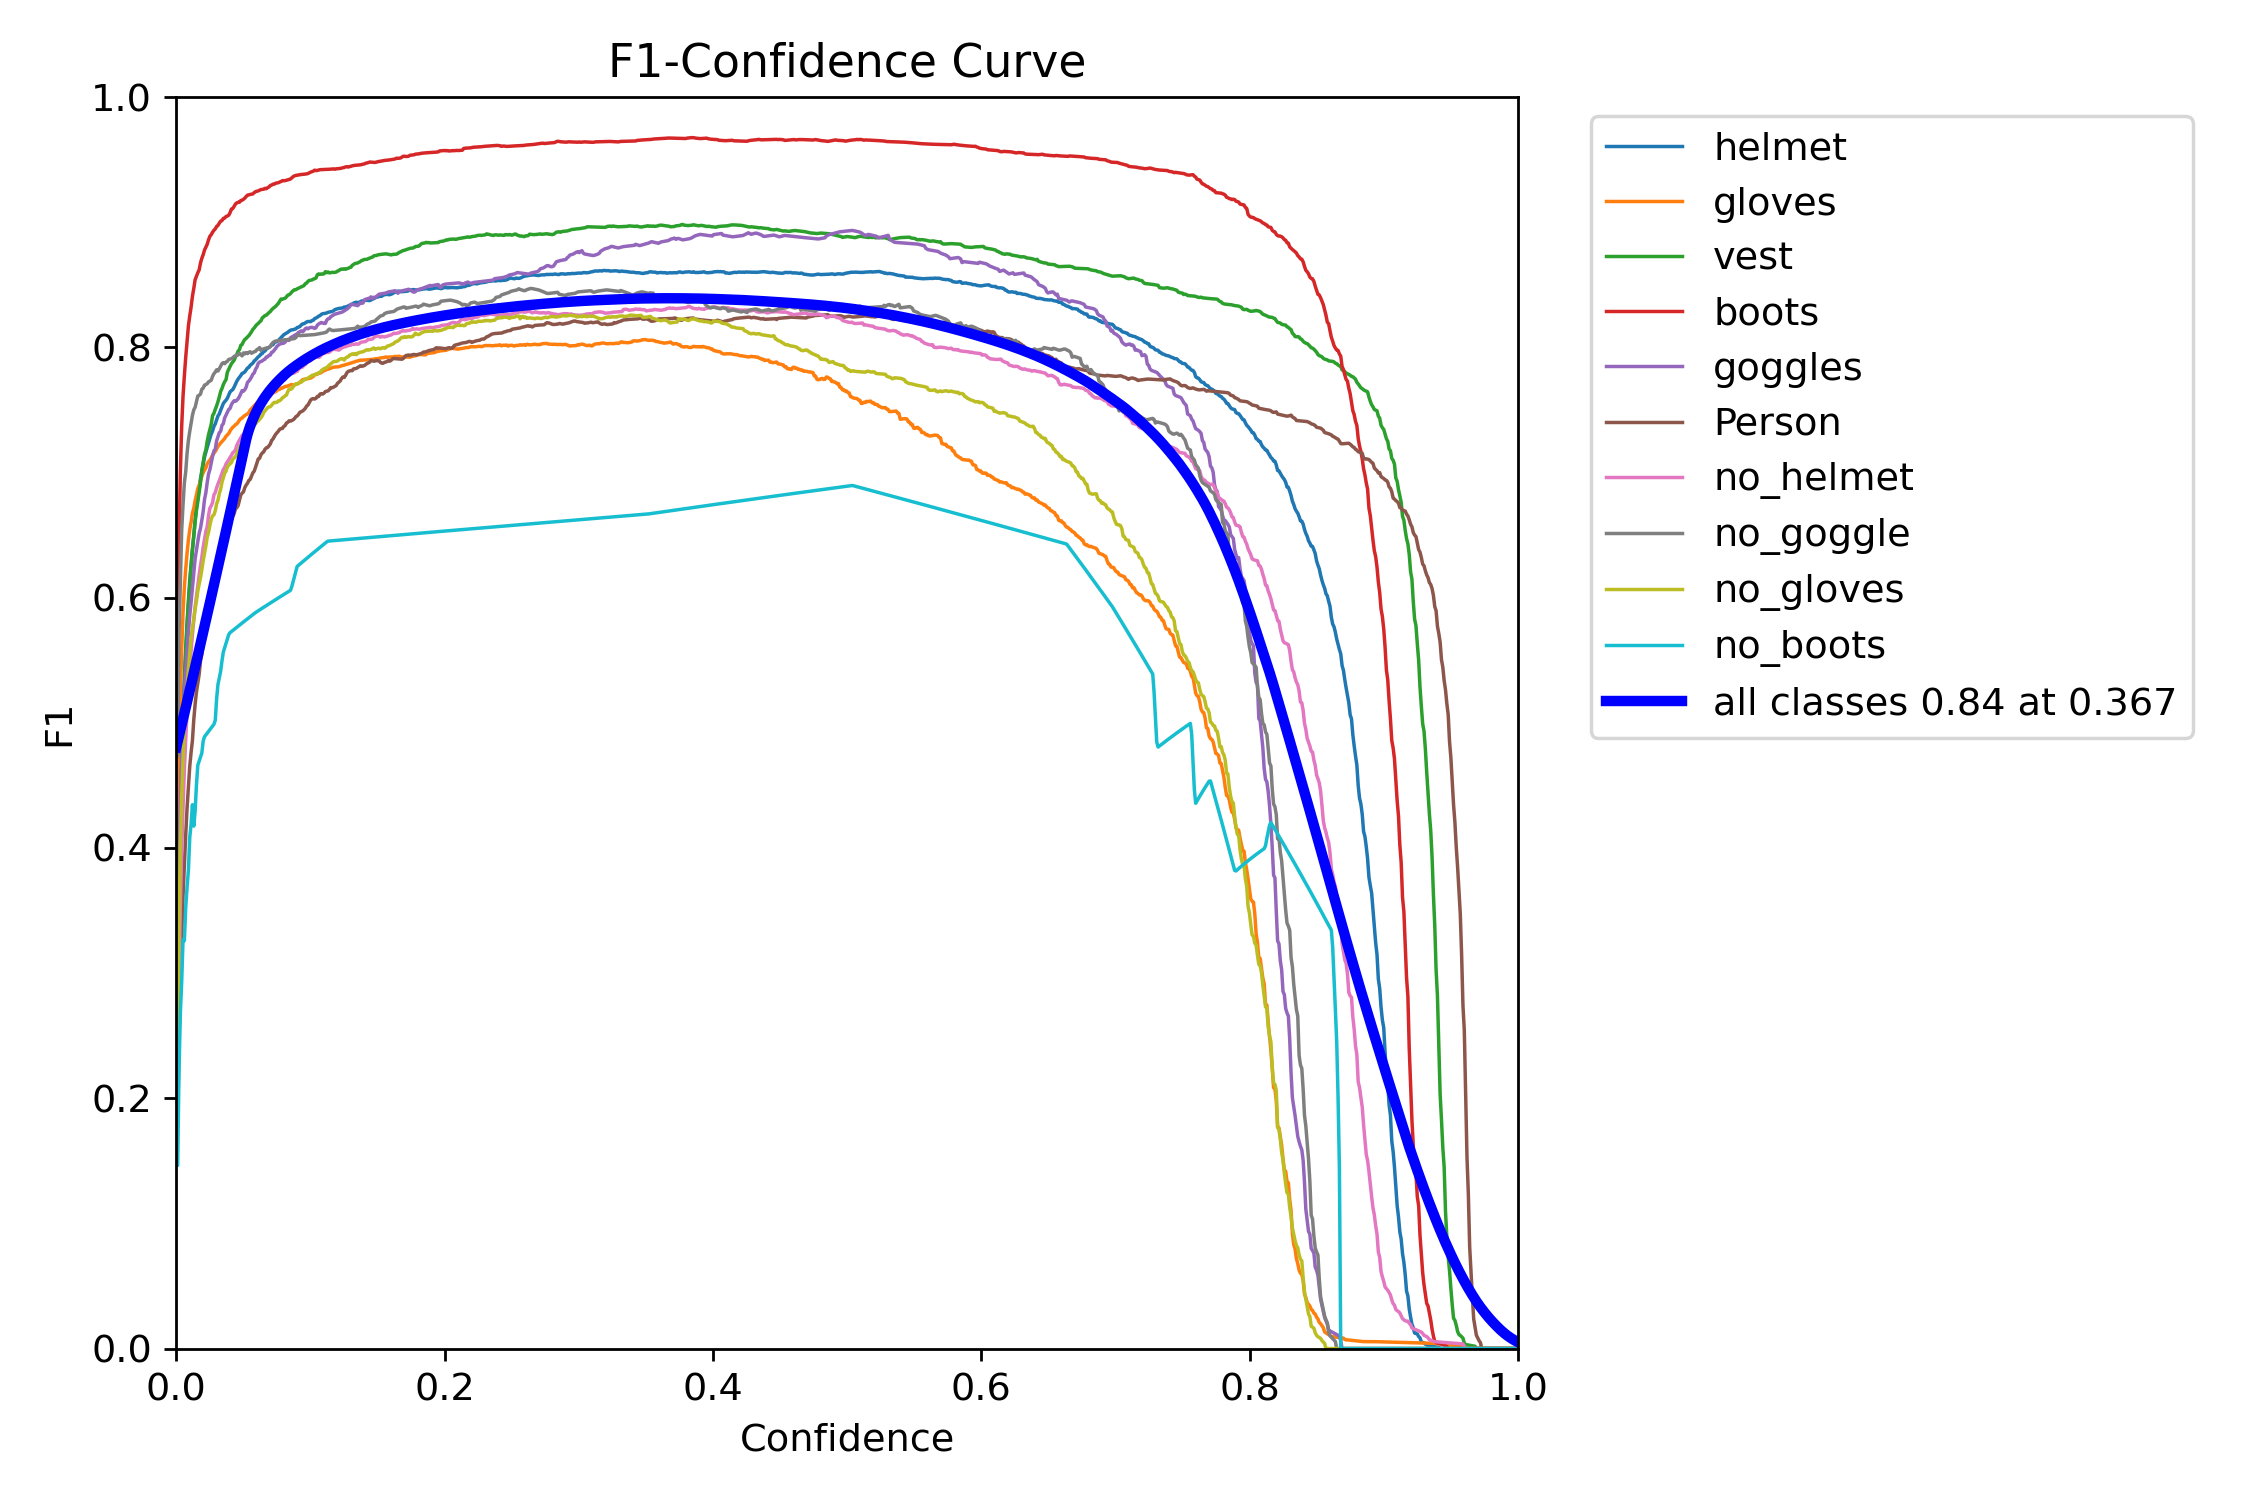

In [19]:
from IPython.display import Image

Image(f"{RUN_DIR}/BoxF1_curve.png")